# Results

Reads the JSON written by both training notebooks.

**Reporting convention.** For the RNN the `R = 5` repetitions were averaged
within each fold during training, so every metric list below holds one entry
per fold. All reported standard deviations and all statistical tests are
therefore computed over the five folds, meaning the variance being tested is
variation across speaker subsets rather than across random initialisations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind
import soundfile as sf

import common
from common import (SEGMENT_LENGTHS, load_metadata, load_turn_times, load_results, compute_metrics)

PRIMARY = "po" # condition reported throughout
SECONDARY = "raw" # condition used for the audio comparison

CONDITION_NAMES = {
    "po": "Participant Speech Only",
    "raw": "Full Interview Recording",
}
CONDITION_SLUGS = {
    "po": "participant_speech_only",
    "raw": "full_interview_recording",
}

import os
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

interview_df, label_of, gender_of, interview_folds = load_metadata()

R = {c: load_results(f"rnn_{c}") for c in [PRIMARY, SECONDARY]}
S = {c: load_results(f"static_{c}") for c in [PRIMARY, SECONDARY]}

random_baseline = S[PRIMARY]["random_baseline"]
print("Loaded:", list(R), list(S))
print("Random baseline F1:", f"{random_baseline['f1']*100:.1f}")

Loaded: ['po', 'raw'] ['po', 'raw']
Random baseline F1: 55.0


In [2]:
print("Random baseline:", {k: f"{v*100:.1f}" for k, v in random_baseline.items()})

Random baseline: {'acc': '50.6', 'precision': '55.1', 'recall': '55.3', 'f1': '55.0'}


In [3]:
def rnn(cond, seg_len, agg):
    return R[cond]["results"][str(seg_len)][agg]

def lr(cond, seg_len, agg):
    return S[cond]["lr"][str(seg_len)][agg]

def svm(cond):
    return S[cond]["svm"]["folds"]

def pooled_rnn(cond, seg_len):
    return R[cond]["results"][str(seg_len)]["pooled"]

def pooled_lr(cond, seg_len):
    return S[cond]["lr"][str(seg_len)]["pooled"]

def mean_metric(metrics_list, metric="f1"):
    return float(np.mean([m[metric] for m in metrics_list]))

In [4]:
summary_rows = []
for cond, label in [("P", "Depressed"), ("C", "Control")]:
    sub = interview_df[interview_df["condition"] == cond]
    summary_rows.append({
        "Group": label,
        "F": (sub["gender"] == "F").sum(),
        "M": (sub["gender"] == "M").sum(),
        "Avg. Age": f"{sub['age'].mean():.1f} ± {sub['age'].std():.1f}",
        "Age Range": f"{sub['age'].min()}-{sub['age'].max()}",
    })
summary_rows.append({
    "Group": "Total",
    "F": (interview_df["gender"] == "F").sum(),
    "M": (interview_df["gender"] == "M").sum(),
    "Avg. Age": f"{interview_df['age'].mean():.1f} ± {interview_df['age'].std():.1f}",
    "Age Range": f"{interview_df['age'].min()}-{interview_df['age'].max()}",
})
pd.DataFrame(summary_rows)

,Group,F,M,Avg. Age,Age Range
0,Depressed,43,21,47.5 ± 11.6,19-68
1,Control,41,11,47.3 ± 12.7,22-71
2,Total,84,32,47.4 ± 12.1,19-71


In [5]:
fold_summary = {}
for fold, speakers in interview_folds.items():
    counts = {"P": 0, "C": 0}
    for s in speakers:
        counts[s.split("_")[1][0]] += 1
    fold_summary[fold] = counts

pd.DataFrame(fold_summary).T.rename(columns={"P": "Depressed", "C": "Control"})

,Depressed,Control
1,12,12
2,13,10
3,10,13
4,18,5
5,11,12


In [6]:
FOLD_COUNTS = {1: (12, 12), 2: (13, 10), 3: (10, 13), 4: (18, 5), 5: (11, 12)}


def fold_table(cond, metric="f1", seg_len=32):
    """Per-fold values for each model at one segment length."""
    rows = {
        "SVM":       [f[metric] for f in svm(cond)],
        "LR (SMV)":  [f[metric] for f in lr(cond, seg_len, "smv")],
        "LR (WA)":   [f[metric] for f in lr(cond, seg_len, "wa")],
        "RNN (SMV)": [f[metric] for f in rnn(cond, seg_len, "smv")],
        "RNN (WA)":  [f[metric] for f in rnn(cond, seg_len, "wa")],
    }
    df = pd.DataFrame(rows, index=[f"Fold {k}" for k in range(1, 6)]).T * 100
    df["Mean"] = df.mean(axis=1)
    df["Std"] = df.iloc[:, :5].std(axis=1, ddof=1)
    return df.round(1)


for metric in ["f1", "precision", "recall"]:
    print(f"\n=== {metric.upper()} by fold, {CONDITION_NAMES[PRIMARY]}, segment length 32 ===")
    print("Fold composition (depressed/control):",
          ", ".join(f"{k}={d}/{c}" for k, (d, c) in FOLD_COUNTS.items()))
    display(fold_table(PRIMARY, metric, 32))

# Is fold 4 consistently the outlier for the temporal model?
print("\n=== RNN (WA) F1 by fold across all segment lengths ===")
display(pd.DataFrame(
    {sl: [f["f1"] * 100 for f in rnn(PRIMARY, sl, "wa")] for sl in SEGMENT_LENGTHS},
    index=[f"Fold {k}" for k in range(1, 6)]
).round(1))


=== F1 by fold, Participant Speech Only, segment length 32 ===
Fold composition (depressed/control): 1=12/12, 2=13/10, 3=10/13, 4=18/5, 5=11/12


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean,Std
SVM,64.3,69.6,57.1,85.7,72.0,69.7,10.6
LR (SMV),62.1,72.0,57.1,75.9,66.7,66.7,7.5
LR (WA),64.3,72.0,60.0,80.0,66.7,68.6,7.7
RNN (SMV),72.0,58.3,56.9,79.0,73.7,68.0,9.8
RNN (WA),72.8,68.2,61.4,79.9,74.8,71.4,7.0



=== PRECISION by fold, Participant Speech Only, segment length 32 ===
Fold composition (depressed/control): 1=12/12, 2=13/10, 3=10/13, 4=18/5, 5=11/12


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean,Std
SVM,56.2,80.0,54.5,88.2,64.3,68.7,14.9
LR (SMV),52.9,75.0,54.5,100.0,61.5,68.8,19.5
LR (WA),56.2,75.0,60.0,100.0,61.5,70.6,17.9
RNN (SMV),70.0,83.2,82.5,100.0,89.5,85.1,10.9
RNN (WA),68.5,86.3,82.1,100.0,88.8,85.1,11.4



=== RECALL by fold, Participant Speech Only, segment length 32 ===
Fold composition (depressed/control): 1=12/12, 2=13/10, 3=10/13, 4=18/5, 5=11/12


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean,Std
SVM,75.0,61.5,60.0,83.3,81.8,72.3,11.0
LR (SMV),75.0,69.2,60.0,61.1,72.7,67.6,6.8
LR (WA),75.0,69.2,60.0,66.7,72.7,68.7,5.8
RNN (SMV),75.0,46.2,44.0,65.6,63.6,58.9,13.3
RNN (WA),78.3,56.9,50.0,66.7,65.5,63.5,10.7



=== RNN (WA) F1 by fold across all segment lengths ===


,32,64,128,256,512,1024
Fold 1,72.8,70.8,65.9,60.7,60.6,63.1
Fold 2,68.2,73.5,73.3,69.5,73.4,80.4
Fold 3,61.4,57.1,56.4,53.1,63.4,56.4
Fold 4,79.9,78.6,82.6,82.3,59.5,42.3
Fold 5,74.8,70.2,69.2,67.8,68.8,66.4


In [7]:
turns_by_speaker = load_turn_times()
participant_durations = {sid: sum(e - s for s, e in pairs) for sid, pairs in turns_by_speaker.items()}

meta_df = pd.DataFrame([
    {"speaker_id": sid, "n_turns": len(turns_by_speaker[sid]), "duration": dur}
    for sid, dur in participant_durations.items()
])
meta_df["condition"] = meta_df["speaker_id"].map(
    dict(zip(interview_df["speaker_id"], interview_df["condition"]))
)
meta_df["gender"] = meta_df["speaker_id"].map(gender_of)

print("Participant-only duration (seconds):")
print(meta_df.groupby("condition")["duration"].agg(["mean", "std", "count", "min", "max"]))

p_dur = meta_df[meta_df["condition"] == "P"]["duration"]
c_dur = meta_df[meta_df["condition"] == "C"]["duration"]
t_stat, p_val = ttest_ind(p_dur, c_dur)
print(f"\nt-test (participant-only duration): t={t_stat:.2f}, p={p_val:.6f}")

Participant-only duration (seconds):
                 mean         std  count      min      max
condition                                                 
C          207.898962   47.260748     52  103.937  388.013
P          176.422859  103.145452     64   34.972  572.021

t-test (participant-only duration): t=-2.03, p=0.044398


In [9]:
meta_raw = []
for _, row in interview_df.iterrows():

    info = sf.info(row["full_recording_path"])
    meta_raw.append({
        "speaker_id":    row["speaker_id"],
        "samplerate": info.samplerate,
        "channels":   info.channels,
        "duration":   info.duration,
    })

meta_df_raw = pd.DataFrame(meta_raw)
meta_df_raw.head(5)

meta_df_raw["condition"] = meta_df_raw["speaker_id"].map(
    dict(zip(interview_df["speaker_id"], interview_df["condition"]))
)
meta_df_raw["gender"] = meta_df_raw["speaker_id"].map(gender_of)

print("Full-Interview duration (seconds):")
print(meta_df_raw.groupby("condition")["duration"].agg(["mean", "std", "count", "min", "max"]))

p_dur_raw = meta_df_raw[meta_df_raw["condition"] == "P"]["duration"]
c_dur_raw = meta_df_raw[meta_df_raw["condition"] == "C"]["duration"]

t_stat_raw, p_val_raw = ttest_ind(p_dur_raw, c_dur_raw)
print(f"t-test (Full-Interview duration): t={t_stat_raw:.2f}, p={p_val_raw:.6f}")

Full-Interview duration (seconds):
                 mean        std  count         min         max
condition                                                      
C          268.022374  45.293864     52  187.129297  429.529297
P          198.822483  99.227922     64   70.649297  579.372698
t-test (Full-Interview duration): t=-4.65, p=0.000009


In [ ]:
def iqr_trim(values):
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    return values[(values >= q1 - 1.5 * iqr) & (values <= q3 + 1.5 * iqr)]

p_trim = iqr_trim(p_dur.values)
c_trim = iqr_trim(c_dur.values)
t_stat, p_val = ttest_ind(p_trim, c_trim)

print(f"Depressed (trimmed): n={len(p_trim)}, mean={p_trim.mean():.1f}, std={p_trim.std():.1f}")
print(f"Control (trimmed):   n={len(c_trim)}, mean={c_trim.mean():.1f}, std={c_trim.std():.1f}")
print(f"t-test (outliers removed): t={t_stat:.2f}, p={p_val:.6f}")

Depressed (trimmed): n=60, mean=157.3, std=69.3
Control (trimmed):   n=51, mean=204.4, std=39.8
t-test (outliers removed): t=-4.24, p=0.000046


In [ ]:
speaker_fold = {s[:4]: k for k, speakers in interview_folds.items() for s in speakers}

check = pd.DataFrame([
    {"sid": sid, "fold": speaker_fold[sid], "gender": gender_of[sid],
     "label": "P" if label_of[sid] else "C"}
    for sid in speaker_fold
])
display(check.groupby(["fold", "gender", "label"]).size().unstack(fill_value=0))

label         C   P
fold gender        
1    F        7  11
     M        5   1
2    F        8   8
     M        2   5
3    F       11   6
     M        2   4
4    F        5   9
     M        0   9
5    F       10   9
     M        2   2

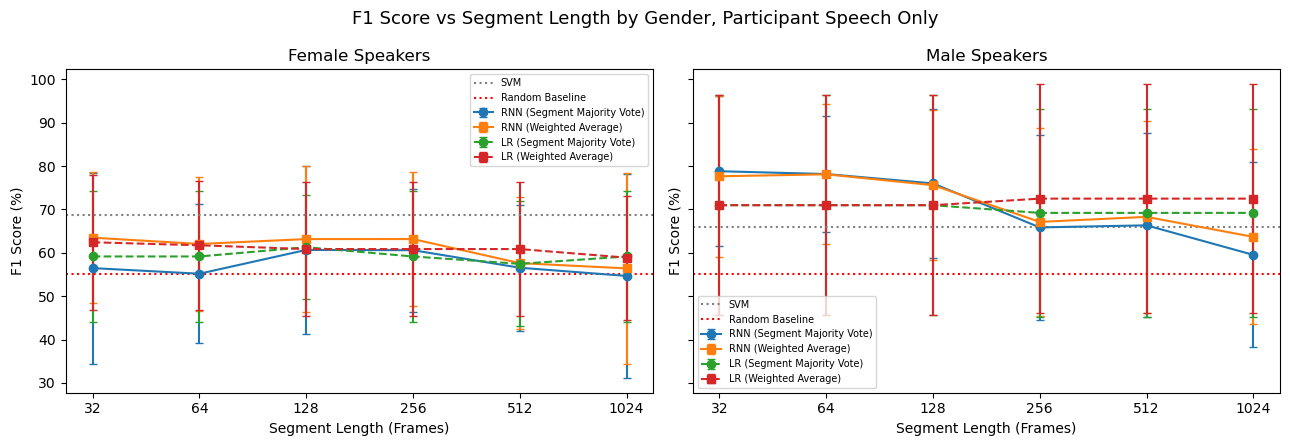

In [ ]:
def gender_fold_metrics(pooled, pred_col, gender, metric="f1"):
    """Per-fold metric for one gender, repetitions averaged within fold."""
    df = pd.DataFrame(pooled)
    df["gender"] = df["sid"].map(gender_of)
    df["fold"] = df["sid"].map(speaker_fold)
    df = df[df["gender"] == gender]

    out = []
    for k in sorted(df["fold"].unique()):
        sub = df[df["fold"] == k]
        if "seed" in sub.columns:
            vals = [compute_metrics(g["y_true"].tolist(), g[pred_col].tolist())[metric]
                    for _, g in sub.groupby("seed")]
            out.append(float(np.mean(vals)))
        else:
            out.append(compute_metrics(sub["y_true"].tolist(), sub[pred_col].tolist())[metric])
    return out


def gender_curves(cond, gender, ax):
    series = [
        ("RNN (Segment Majority Vote)", lambda s: gender_fold_metrics(pooled_rnn(cond, s), "y_pred_smv", gender), "o-"),
        ("RNN (Weighted Average)",      lambda s: gender_fold_metrics(pooled_rnn(cond, s), "y_pred_wa", gender),  "s-"),
        ("LR (Segment Majority Vote)",  lambda s: gender_fold_metrics(pooled_lr(cond, s), "y_pred_smv", gender),  "o--"),
        ("LR (Weighted Average)",       lambda s: gender_fold_metrics(pooled_lr(cond, s), "y_pred_wa", gender),   "s--"),
    ]
    x = np.arange(len(SEGMENT_LENGTHS))
    for label, getter, style in series:
        vals = [getter(s) for s in SEGMENT_LENGTHS]
        means = [np.mean(v) * 100 for v in vals]
        errs = [np.std(v, ddof=1) * 100 for v in vals]
        ax.errorbar(x, means, yerr=errs, fmt=style, capsize=3, label=label)

    svm_vals = gender_fold_metrics(S[cond]["svm"]["pooled"], "y_pred", gender)
    ax.axhline(np.mean(svm_vals) * 100, color="grey", ls=":", label="SVM")
    ax.axhline(random_baseline["f1"] * 100, color="red", ls=":", label="Random Baseline")

    ax.set_xticks(x)
    ax.set_xticklabels(SEGMENT_LENGTHS)
    ax.set_xlabel("Segment Length (Frames)")
    ax.set_ylabel("F1 Score (%)")
    ax.set_title(f"{'Female' if gender == 'F' else 'Male'} Speakers")
    ax.legend(fontsize=7)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
gender_curves(PRIMARY, "F", axes[0])
gender_curves(PRIMARY, "M", axes[1])
fig.suptitle(f"F1 Score vs Segment Length by Gender, {CONDITION_NAMES[PRIMARY]}", fontsize=13)
plt.tight_layout()
plt.savefig(f"figures/f1_score_vs_segment_length_by_gender_{CONDITION_SLUGS[PRIMARY]}.png",
            dpi=200, bbox_inches="tight")
plt.show()

## Performance summary

In [ ]:
def summary_row(model_name, seg_len, folds, pooled, pred_col):
    row = {"Model": model_name, "Segment Length": seg_len}
    for metric in ["acc", "precision", "recall", "f1"]:
        vals = [f[metric] for f in folds]
        row[metric.capitalize()] = f"{np.mean(vals)*100:.1f} ± {np.std(vals, ddof=1)*100:.1f}"

    df_preds = pd.DataFrame(pooled)
    df_preds["gender"] = df_preds["sid"].map(gender_of)
    for g, label in [("F", "Female"), ("M", "Male")]:
        sub = df_preds[df_preds["gender"] == g]
        m = compute_metrics(sub["y_true"].tolist(), sub[pred_col].tolist())
        row[f"{label} F1"] = round(m["f1"] * 100, 1)
    return row


def summary_table(cond):
    rows = []
    sv = S[cond]["svm"]
    rows.append(summary_row("SVM", "-", sv["folds"], sv["pooled"], "y_pred"))
    for agg, col in [("smv", "y_pred_smv"), ("wa", "y_pred_wa")]:
        for seg_len in SEGMENT_LENGTHS:
            rows.append(summary_row(f"LR ({agg.upper()})", seg_len, lr(cond, seg_len, agg), pooled_lr(cond, seg_len), col))
    for agg, col in [("smv", "y_pred_smv"), ("wa", "y_pred_wa")]:
        for seg_len in SEGMENT_LENGTHS:
            rows.append(summary_row(f"RNN ({agg.upper()})", seg_len, rnn(cond, seg_len, agg), pooled_rnn(cond, seg_len), col))
    return pd.DataFrame(rows).set_index(["Model", "Segment Length"])


print(CONDITION_NAMES[PRIMARY])
display(summary_table(PRIMARY))

Participant Speech Only


Acc    Precision       Recall           F1  \
Model     Segment Length                                                       
SVM       -                67.3 ± 7.9  68.7 ± 14.9  72.3 ± 11.0  69.7 ± 10.6   
LR (SMV)  32               63.9 ± 6.5  68.8 ± 19.5   67.6 ± 6.8   66.7 ± 7.5   
          64               63.9 ± 6.5  68.8 ± 19.5   67.6 ± 6.8   66.7 ± 7.5   
          128              65.6 ± 4.6  71.1 ± 17.6   70.2 ± 9.9   68.7 ± 2.8   
          256              63.0 ± 7.3  67.9 ± 20.4   67.6 ± 6.8   66.2 ± 8.4   
          512              63.0 ± 5.8  68.4 ± 19.3   66.1 ± 7.2   65.7 ± 6.9   
          1024             63.0 ± 7.3  67.9 ± 20.4   67.6 ± 6.8   66.2 ± 8.4   
LR (WA)   32               66.4 ± 5.8  70.6 ± 17.9   68.7 ± 5.8   68.6 ± 7.7   
          64               65.6 ± 7.3  69.9 ± 18.6   68.7 ± 5.8   68.1 ± 8.1   
          128              65.6 ± 6.3  69.9 ± 18.4   66.9 ± 5.7   67.4 ± 8.5   
          256              66.4 ± 7.2  71.3 ± 19.1   66.9 ± 5.7   68.0 ± 9.0   
          512              66.4 ± 7.2  71.3 ± 19.1   66.9 ± 5.7   68.0 ± 9.0   
          1024             65.6 ± 6.3  71.3 ± 19.1   65.8 ± 6.3   67.2 ± 7.7   
RNN (SMV) 32               71.7 ± 5.0  85.1 ± 10.9  58.9 ± 13.3   68.0 ± 9.8   
          64               69.3 ± 3.0  82.7 ± 10.7   55.3 ± 8.1   65.6 ± 7.0   
          128              70.7 ± 4.1  78.5 ± 12.8  60.7 ± 10.4  68.1 ± 10.8   
          256              64.9 ± 6.3  70.9 ± 16.9   60.0 ± 8.2  64.2 ± 10.3   
          512              60.2 ± 7.6  68.1 ± 19.1  65.5 ± 15.5   63.2 ± 7.5   
          1024            57.6 ± 11.3  62.5 ± 13.1  65.5 ± 21.4  59.5 ± 14.8   
RNN (WA)  32               73.5 ± 3.5  85.1 ± 11.4  63.5 ± 10.7   71.4 ± 7.0   
          64               71.7 ± 1.7  80.1 ± 11.3   63.1 ± 8.5   70.0 ± 8.0   
          128              71.1 ± 3.5  77.6 ± 12.5   63.5 ± 9.4   69.5 ± 9.6   
          256              66.8 ± 6.8  71.7 ± 17.7   63.5 ± 8.4  66.7 ± 10.9   
          512              61.8 ± 6.1  68.6 ± 18.5  68.0 ± 14.2   65.1 ± 5.8   
          1024            59.0 ± 11.0  64.2 ± 12.7  68.7 ± 21.2  61.7 ± 13.9   

                          Female F1  Male F1  
Model     Segment Length                      
SVM       -                    69.8     73.9  
LR (SMV)  32                   61.5     76.0  
          64                   61.5     76.0  
          128                  64.1     76.0  
          256                  61.5     74.5  
          512                  60.5     74.5  
          1024                 61.5     74.5  
LR (WA)   32                   64.9     76.0  
          64                   64.1     76.0  
          128                  63.2     76.0  
          256                  63.2     77.6  
          512                  63.2     77.6  
          1024                 61.3     77.6  
RNN (SMV) 32                   62.4     82.5  
          64                   58.3     80.6  
          128                  63.8     80.4  
          256                  62.6     70.4  
          512                  59.3     70.2  
          1024                 60.0     65.2  
RNN (WA)  32                   67.2     81.9  
          64                   64.8     82.5  
          128                  65.8     80.2  
          256                  65.4     72.3  
          512                  61.0     72.7  
          1024                 61.3     68.1

In [ ]:
print(CONDITION_NAMES[SECONDARY])
display(summary_table(SECONDARY))

Full Interview Recording


Acc    Precision       Recall           F1  \
Model     Segment Length                                                       
SVM       -                80.2 ± 4.9  80.9 ± 11.2   82.8 ± 6.3   81.4 ± 6.7   
LR (SMV)  32              62.1 ± 10.9  74.1 ± 21.8  54.5 ± 10.1   60.9 ± 9.9   
          64               62.1 ± 9.5  73.4 ± 19.2  54.5 ± 10.1   60.8 ± 8.3   
          128              62.1 ± 9.5  73.4 ± 19.2  54.5 ± 10.1   60.8 ± 8.3   
          256              60.4 ± 8.5  70.8 ± 20.4  54.5 ± 10.1   59.6 ± 8.2   
          512              61.3 ± 8.2  71.9 ± 19.1  54.5 ± 10.1   60.2 ± 7.5   
          1024             60.4 ± 9.0  71.9 ± 20.4   52.9 ± 9.4   59.1 ± 7.8   
LR (WA)   32               64.7 ± 9.3  76.6 ± 18.8   55.6 ± 8.1   63.2 ± 7.9   
          64               64.7 ± 9.3  76.6 ± 18.8   55.6 ± 8.1   63.2 ± 7.9   
          128              64.7 ± 9.3  76.6 ± 18.8   55.6 ± 8.1   63.2 ± 7.9   
          256              64.7 ± 9.3  76.6 ± 18.8   55.6 ± 8.1   63.2 ± 7.9   
          512              64.7 ± 9.3  76.6 ± 18.8   55.6 ± 8.1   63.2 ± 7.9   
          1024             64.7 ± 9.3  76.6 ± 18.8   55.6 ± 8.1   63.2 ± 7.9   
RNN (SMV) 32               77.2 ± 3.8   94.8 ± 5.9   62.6 ± 6.7   74.7 ± 3.3   
          64               72.4 ± 3.6   94.2 ± 5.8   52.8 ± 7.4   66.9 ± 6.2   
          128              69.7 ± 2.8  80.7 ± 10.2  56.7 ± 10.8   65.7 ± 9.9   
          256              70.3 ± 2.8   80.9 ± 8.6  57.9 ± 10.6   66.8 ± 8.9   
          512              63.2 ± 7.5  77.2 ± 16.9   49.4 ± 2.4   59.3 ± 4.6   
          1024            51.0 ± 14.7   59.5 ± 5.8  36.5 ± 17.7  42.3 ± 17.8   
RNN (WA)  32               77.4 ± 2.6   92.5 ± 6.4   64.2 ± 7.1   75.1 ± 4.8   
          64               72.7 ± 2.2   88.1 ± 5.3   57.8 ± 7.8   69.0 ± 7.1   
          128              70.7 ± 2.6  80.0 ± 10.5   60.9 ± 9.6   68.2 ± 8.4   
          256              70.7 ± 3.3   80.5 ± 9.7  58.7 ± 10.4   67.4 ± 9.3   
          512              64.4 ± 8.7  76.4 ± 17.8   53.5 ± 7.1   62.0 ± 8.3   
          1024            53.8 ± 14.6  70.0 ± 18.1  43.3 ± 18.9  48.3 ± 17.1   

                          Female F1  Male F1  
Model     Segment Length                      
SVM       -                    78.0     89.4  
LR (SMV)  32                   48.5     78.3  
          64                   49.2     76.6  
          128                  49.2     76.6  
          256                  47.8     76.6  
          512                  48.5     76.6  
          1024                 46.2     76.6  
LR (WA)   32                   52.3     78.3  
          64                   52.3     78.3  
          128                  52.3     78.3  
          256                  52.3     78.3  
          512                  52.3     78.3  
          1024                 52.3     78.3  
RNN (SMV) 32                   68.5     86.9  
          64                   57.7     85.4  
          128                  58.1     83.9  
          256                  59.1     84.8  
          512                  48.9     74.2  
          1024                 39.6     47.9  
RNN (WA)  32                   69.4     87.4  
          64                   61.5     85.4  
          128                  61.8     83.7  
          256                  59.9     85.2  
          512                  51.9     76.2  
          1024                 46.8     51.8

## Statistical comparisons

Two families of tests, each Bonferroni-corrected:

- **Temporal vs static**: RNN against LR under a matched aggregation strategy (2 comparisons, α = 0.025)
- **Above chance**: each model/aggregation combination against the random baseline (4 comparisons, α = 0.0125)

In [ ]:
def paired_stats(metrics_a, metrics_b, metric="f1"):
    a = np.array([m[metric] for m in metrics_a])
    b = np.array([m[metric] for m in metrics_b])
    t_stat, p_val = stats.ttest_rel(a, b)
    return (a - b).mean() * 100, t_stat, p_val


def vs_random_stats(metrics, baseline, metric="f1"):
    a = np.array([m[metric] for m in metrics])
    t_stat, p_val = stats.ttest_1samp(a, baseline[metric], alternative="greater")
    return a.mean() * 100 - baseline[metric] * 100, t_stat, p_val


alpha = 0.05
temporal_vs_static_alpha = alpha / 2
above_chance_alpha = alpha / 4


def model_stats(cond):
    rows = []
    for seg_len in SEGMENT_LENGTHS:
        for agg in ["smv", "wa"]:
            d, t, p = paired_stats(rnn(cond, seg_len, agg), lr(cond, seg_len, agg))
            rows.append({"segment_length": seg_len, "question": "Temporal vs Static",
                         "comparison": f"RNN ({agg.upper()}) vs LR ({agg.upper()})",
                         "mean_diff_f1_%": round(d, 2), "t_stat": round(t, 2),
                         "p_raw": round(p, 4), "corrected_alpha": temporal_vs_static_alpha,
                         "significant": p < temporal_vs_static_alpha})

        for label, m in [("RNN (SMV)", rnn(cond, seg_len, "smv")),
                         ("RNN (WA)", rnn(cond, seg_len, "wa")),
                         ("LR (SMV)", lr(cond, seg_len, "smv")),
                         ("LR (WA)", lr(cond, seg_len, "wa"))]:
            d, t, p = vs_random_stats(m, random_baseline)
            rows.append({"segment_length": seg_len, "question": "Above Chance",
                         "comparison": f"{label} vs Random",
                         "mean_diff_f1_%": round(d, 2), "t_stat": round(t, 2),
                         "p_raw": round(p, 4), "corrected_alpha": above_chance_alpha,
                         "significant": p < above_chance_alpha})
    return pd.DataFrame(rows).sort_values(["segment_length", "question", "comparison"]).reset_index(drop=True)


stats_primary = model_stats(PRIMARY)
stats_primary

,segment_length,question,comparison,mean_diff_f1_%,t_stat,p_raw,corrected_alpha,significant
0,32,Above Chance,LR (SMV) vs Random,11.74,3.50,0.0124,0.0125,True
1,32,Above Chance,LR (WA) vs Random,13.58,3.94,0.0085,0.0125,True
2,32,Above Chance,RNN (SMV) vs Random,12.96,2.94,0.0211,0.0125,False
3,32,Above Chance,RNN (WA) vs Random,16.42,5.24,0.0032,0.0125,True
4,32,Temporal vs Static,RNN (SMV) vs LR (SMV),1.22,0.30,0.7818,0.0250,False
5,32,Temporal vs Static,RNN (WA) vs LR (WA),2.84,1.18,0.3032,0.0250,False
6,64,Above Chance,LR (SMV) vs Random,11.74,3.50,0.0124,0.0125,True
7,64,Above Chance,LR (WA) vs Random,13.14,3.64,0.0110,0.0125,True
8,64,Above Chance,RNN (SMV) vs Random,10.56,3.38,0.0139,0.0125,False
9,64,Above Chance,RNN (WA) vs Random,15.01,4.21,0.0068,0.0125,True


In [ ]:
stats_secondary = model_stats(SECONDARY)
stats_secondary

,segment_length,question,comparison,mean_diff_f1_%,t_stat,p_raw,corrected_alpha,significant
0,32,Above Chance,LR (SMV) vs Random,5.94,1.35,0.1249,0.0125,False
1,32,Above Chance,LR (WA) vs Random,8.16,2.31,0.0412,0.0125,False
2,32,Above Chance,RNN (SMV) vs Random,19.68,13.42,0.0001,0.0125,True
3,32,Above Chance,RNN (WA) vs Random,20.10,9.30,0.0004,0.0125,True
4,32,Temporal vs Static,RNN (SMV) vs LR (SMV),13.74,3.03,0.0386,0.0250,False
5,32,Temporal vs Static,RNN (WA) vs LR (WA),11.94,3.03,0.0389,0.0250,False
6,64,Above Chance,LR (SMV) vs Random,5.83,1.57,0.0952,0.0125,False
7,64,Above Chance,LR (WA) vs Random,8.16,2.31,0.0412,0.0125,False
8,64,Above Chance,RNN (SMV) vs Random,11.93,4.30,0.0063,0.0125,True
9,64,Above Chance,RNN (WA) vs Random,13.97,4.37,0.0060,0.0125,True


## SVM comparison

In [ ]:
svm_alpha = 0.05 / 2

def svm_stats(cond):
    best_f1, best_label, best_metrics = -1, None, None
    for seg_len in SEGMENT_LENGTHS:
        for agg in ["smv", "wa"]:
            m = rnn(cond, seg_len, agg)
            if mean_metric(m) > best_f1:
                best_f1, best_metrics = mean_metric(m), m
                best_label = f"RNN ({agg.upper()}) @ seg_len={seg_len}"

    rows = []
    d, t, p = paired_stats(best_metrics, svm(cond))
    rows.append({"comparison": f"Best {best_label} vs SVM", "mean_diff_f1_%": round(d, 2),
                 "t_stat": round(t, 2), "p_raw": round(p, 4),
                 "corrected_alpha": svm_alpha, "significant": p < svm_alpha})

    d, t, p = vs_random_stats(svm(cond), random_baseline)
    rows.append({"comparison": "SVM vs Random", "mean_diff_f1_%": round(d, 2),
                 "t_stat": round(t, 2), "p_raw": round(p, 4),
                 "corrected_alpha": svm_alpha, "significant": p < svm_alpha})
    return pd.DataFrame(rows)


print(CONDITION_NAMES[PRIMARY]);   display(svm_stats(PRIMARY))
print(CONDITION_NAMES[SECONDARY]); display(svm_stats(SECONDARY))

Participant Speech Only


,comparison,mean_diff_f1_%,t_stat,p_raw,corrected_alpha,significant
0,Best RNN (WA) @ seg_len=32 vs SVM,1.69,0.69,0.5295,0.025,False
1,SVM vs Random,14.73,3.11,0.0179,0.025,True


Full Interview Recording


,comparison,mean_diff_f1_%,t_stat,p_raw,corrected_alpha,significant
0,Best RNN (WA) @ seg_len=32 vs SVM,-6.34,-2.18,0.0950,0.025,False
1,SVM vs Random,26.44,8.88,0.0004,0.025,True


## Audio condition comparison

Whether including the interviewer's speech changes the conclusions. Four
comparisons per segment length, Bonferroni-corrected to α = 0.0125. Both sides
are fold-level and matched on the same folds, so the tests are paired.

In [ ]:
audio_alpha = 0.05 / 4
rows = []

for seg_len in SEGMENT_LENGTHS:
    comparisons = [
        ("LR (SMV)",  lr(SECONDARY, seg_len, "smv"),  lr(PRIMARY, seg_len, "smv")),
        ("LR (WA)",   lr(SECONDARY, seg_len, "wa"),   lr(PRIMARY, seg_len, "wa")),
        ("RNN (SMV)", rnn(SECONDARY, seg_len, "smv"), rnn(PRIMARY, seg_len, "smv")),
        ("RNN (WA)",  rnn(SECONDARY, seg_len, "wa"),  rnn(PRIMARY, seg_len, "wa")),
    ]
    for label, m_raw, m_po in comparisons:
        d, t, p = paired_stats(m_raw, m_po)
        rows.append({"segment_length": seg_len,
                     "question": "Full Interview vs Participant Speech Only",
                     "comparison": label,
                     "mean_diff_f1_%": round(d, 2), "t_stat": round(t, 2),
                     "p_raw": round(p, 4), "corrected_alpha": audio_alpha,
                     "significant": p < audio_alpha})

audio_stats = pd.DataFrame(rows).sort_values(["segment_length", "comparison"]).reset_index(drop=True)
audio_stats

,segment_length,question,comparison,mean_diff_f1_%,t_stat,p_raw,corrected_alpha,significant
0,32,Full Interview vs Participant Speech Only,LR (SMV),-5.80,-1.44,0.2238,0.0125,False
1,32,Full Interview vs Participant Speech Only,LR (WA),-5.43,-1.42,0.2297,0.0125,False
2,32,Full Interview vs Participant Speech Only,RNN (SMV),6.72,2.13,0.1005,0.0125,False
3,32,Full Interview vs Participant Speech Only,RNN (WA),3.68,2.36,0.0781,0.0125,False
4,64,Full Interview vs Participant Speech Only,LR (SMV),-5.91,-1.54,0.1982,0.0125,False
5,64,Full Interview vs Participant Speech Only,LR (WA),-4.98,-1.32,0.2572,0.0125,False
6,64,Full Interview vs Participant Speech Only,RNN (SMV),1.37,0.87,0.4347,0.0125,False
7,64,Full Interview vs Participant Speech Only,RNN (WA),-1.04,-2.51,0.0658,0.0125,False
8,128,Full Interview vs Participant Speech Only,LR (SMV),-7.85,-2.18,0.0943,0.0125,False
9,128,Full Interview vs Participant Speech Only,LR (WA),-4.27,-0.93,0.4056,0.0125,False


In [ ]:
d, t, p = paired_stats(svm(SECONDARY), svm(PRIMARY))
print(f"SVM, {CONDITION_NAMES[SECONDARY]} vs {CONDITION_NAMES[PRIMARY]}: "
      f"{mean_metric(svm(SECONDARY))*100:.1f} vs {mean_metric(svm(PRIMARY))*100:.1f} F1, "
      f"diff {d:+.2f}, t={t:.2f}, p={p:.4f}")

SVM, Full Interview Recording vs Participant Speech Only: 81.4 vs 69.7 F1, diff +11.70, t=2.78, p=0.0499


## Figures

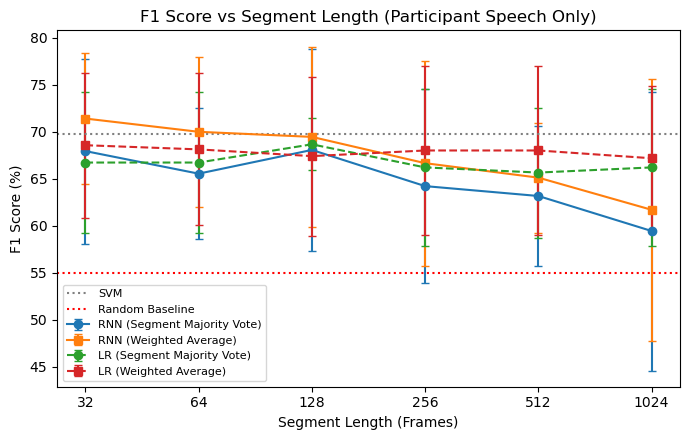

Saved figures/f1_score_vs_segment_length_participant_speech_only.png


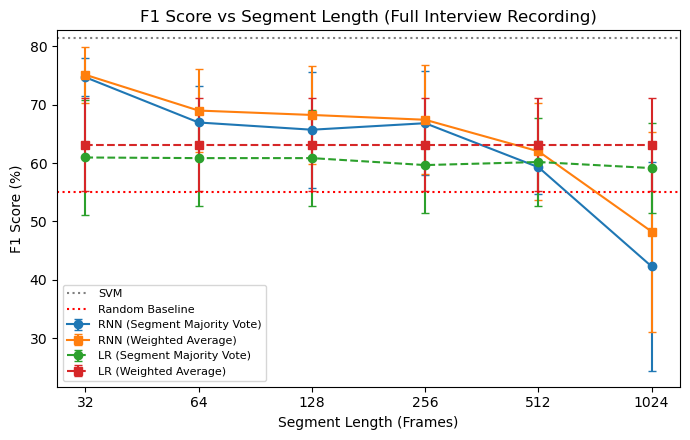

Saved figures/f1_score_vs_segment_length_full_interview_recording.png


In [ ]:
METRIC_LABELS = {"f1": "F1 Score", "acc": "Accuracy"}


def performance_curves(cond, metric="f1", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4.5))
    x = np.arange(len(SEGMENT_LENGTHS))

    series = [
        ("RNN (Segment Majority Vote)", lambda s: rnn(cond, s, "smv"), "o-"),
        ("RNN (Weighted Average)",      lambda s: rnn(cond, s, "wa"),  "s-"),
        ("LR (Segment Majority Vote)",  lambda s: lr(cond, s, "smv"),  "o--"),
        ("LR (Weighted Average)",       lambda s: lr(cond, s, "wa"),   "s--"),
    ]
    for label, getter, style in series:
        means = [np.mean([f[metric] for f in getter(s)]) * 100 for s in SEGMENT_LENGTHS]
        errs = [np.std([f[metric] for f in getter(s)], ddof=1) * 100 for s in SEGMENT_LENGTHS]
        ax.errorbar(x, means, yerr=errs, fmt=style, capsize=3, label=label)

    ax.axhline(mean_metric(svm(cond), metric) * 100, color="grey", ls=":", label="SVM")
    ax.axhline(random_baseline[metric] * 100, color="red", ls=":", label="Random Baseline")

    ax.set_xticks(x)
    ax.set_xticklabels(SEGMENT_LENGTHS)
    ax.set_xlabel("Segment Length (Frames)")
    ax.set_ylabel(f"{METRIC_LABELS[metric]} (%)")
    ax.set_title(f"{METRIC_LABELS[metric]} vs Segment Length ({CONDITION_NAMES[cond]})")
    ax.legend(fontsize=8)
    return ax


def save_performance_figure(cond, metric):
    """One figure per condition per metric, saved under its own filename."""
    fig, ax = plt.subplots(figsize=(7, 4.5))
    performance_curves(cond, metric, ax)
    plt.tight_layout()
    name = f"figures/{'f1_score' if metric == 'f1' else 'accuracy'}_vs_segment_length_{CONDITION_SLUGS[cond]}.png"
    plt.savefig(name, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved", name)


save_performance_figure(PRIMARY, "f1")
save_performance_figure(SECONDARY, "f1")

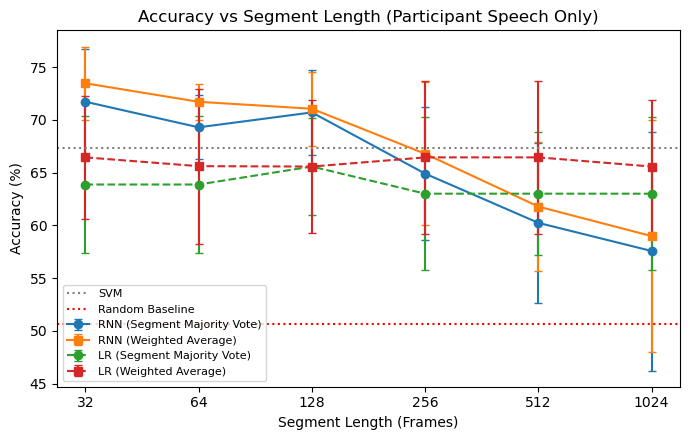

Saved figures/accuracy_vs_segment_length_participant_speech_only.png


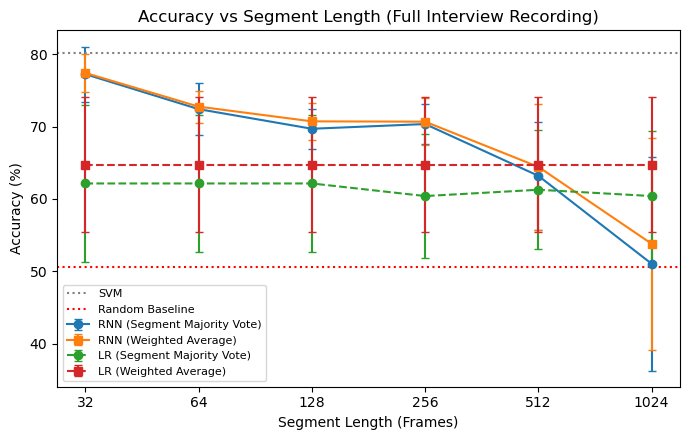

Saved figures/accuracy_vs_segment_length_full_interview_recording.png


In [ ]:
save_performance_figure(PRIMARY, "acc")
save_performance_figure(SECONDARY, "acc")

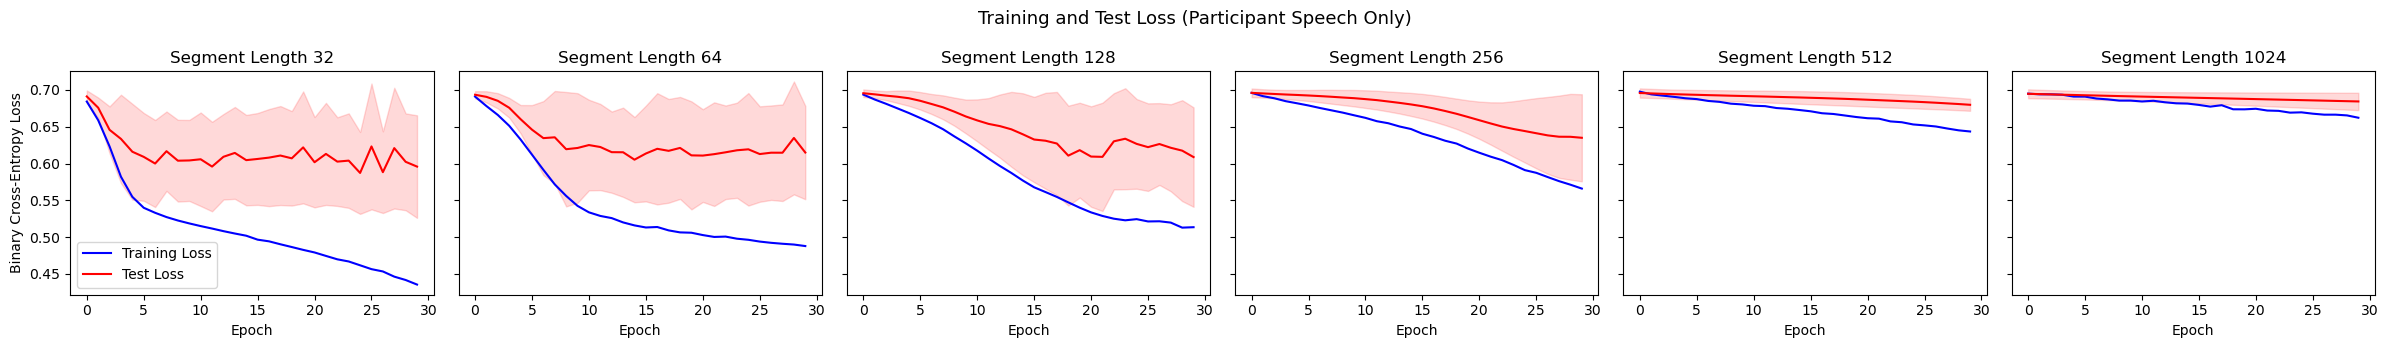

Saved figures/training_loss_participant_speech_only.png


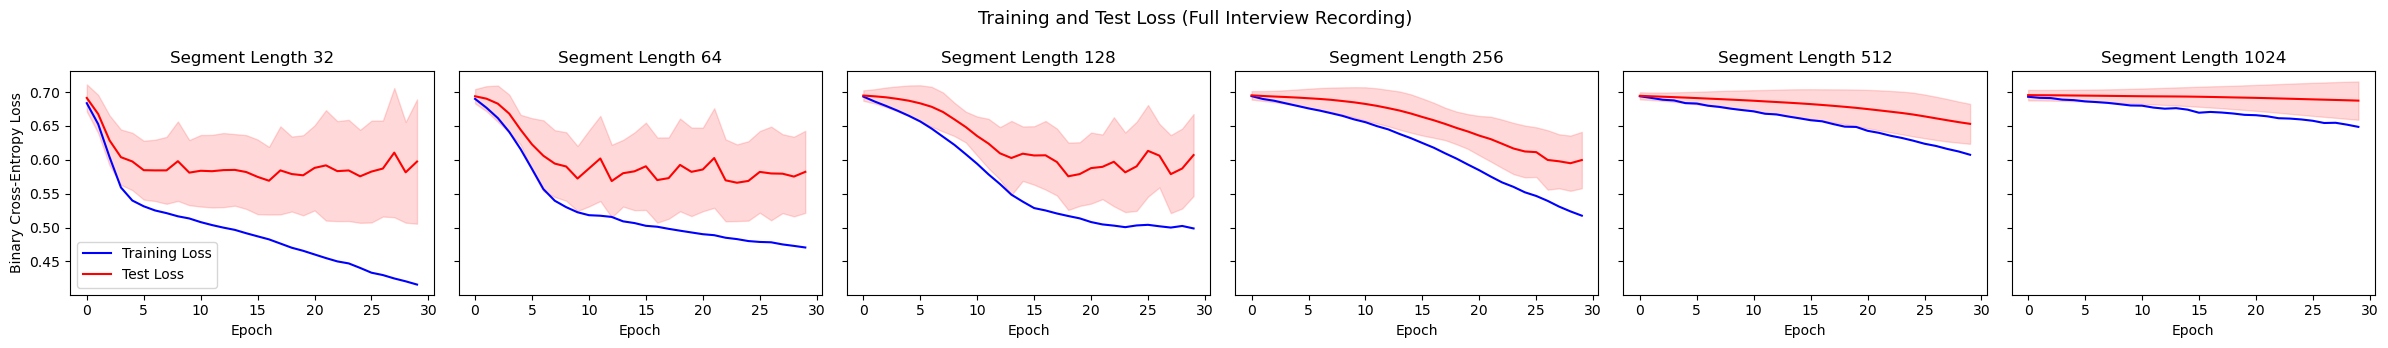

Saved figures/training_loss_full_interview_recording.png


In [ ]:
def save_loss_figure(cond):
    fig, axes = plt.subplots(1, len(SEGMENT_LENGTHS),
                             figsize=(4 * len(SEGMENT_LENGTHS), 3.5), sharey=True)

    for ax, seg_len in zip(axes, SEGMENT_LENGTHS):
        curves = R[cond]["results"][str(seg_len)]["loss_curves"]
        train_arr = np.array([c["train"] for c in curves.values()])
        test_arr = np.array([c["test"] for c in curves.values()])

        ax.plot(train_arr.mean(axis=0), color="blue", label="Training Loss")
        ax.plot(test_arr.mean(axis=0), color="red", label="Test Loss")
        ax.fill_between(range(train_arr.shape[1]),
                        test_arr.mean(axis=0) - test_arr.std(axis=0),
                        test_arr.mean(axis=0) + test_arr.std(axis=0),
                        color="red", alpha=0.15)
        ax.set_title(f"Segment Length {seg_len}")
        ax.set_xlabel("Epoch")

    axes[0].set_ylabel("Binary Cross-Entropy Loss")
    axes[0].legend()
    fig.suptitle(f"Training and Test Loss ({CONDITION_NAMES[cond]})", fontsize=13)
    plt.tight_layout()
    name = f"figures/training_loss_{CONDITION_SLUGS[cond]}.png"
    plt.savefig(name, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved", name)


save_loss_figure(PRIMARY)
save_loss_figure(SECONDARY)

## Export tables

In [ ]:
summary_table(PRIMARY).to_csv(f"results/summary_{CONDITION_SLUGS[PRIMARY]}.csv")
summary_table(SECONDARY).to_csv(f"results/summary_{CONDITION_SLUGS[SECONDARY]}.csv")
stats_primary.to_csv(f"results/statistics_{CONDITION_SLUGS[PRIMARY]}.csv", index=False)
stats_secondary.to_csv(f"results/statistics_{CONDITION_SLUGS[SECONDARY]}.csv", index=False)
audio_stats.to_csv("results/statistics_audio_condition_comparison.csv", index=False)
print("Tables written to results/")

Tables written to results/


In [ ]:
def to_latex(df, path):
    with open(path, "w") as f:
        for _, r in df.iterrows():
            f.write(" & ".join(str(v) for v in r) + r" \\" + "\n")

to_latex(stats_secondary.reset_index(), "results/tab_a4.tex")

# Generating tables for final write up (latex)

In [ ]:
def to_latex(df, path, cols=None):
    if cols is not None:
        df = df[cols]
    with open(path, "w") as f:
        for _, r in df.iterrows():
            f.write(" & ".join(str(v) for v in r) + r" \\" + "\n")

stat_cols = ["segment_length", "question", "comparison",
             "mean_diff_f1_%", "t_stat", "p_raw", "corrected_alpha"]

to_latex(stats_primary,   "results/tab_a3.tex", stat_cols)
to_latex(stats_secondary, "results/tab_a4.tex", stat_cols)

to_latex(summary_table(PRIMARY).reset_index(),   "results/tab_a1.tex")
to_latex(summary_table(SECONDARY).reset_index(), "results/tab_a2.tex")

to_latex(audio_stats, "results/tab_a5.tex", stat_cols)